Task 1: Dataset Exploration (15 Marks) 
Before developing any deep learning models, analyse the Kahikatea image dataset to 
understand its structure, characteristics, and potential challenges for image 
classification.  
Describe the dataset organisation analysing the class distribution and image properties 
such as dimensions, aspect ratios, colour channels, brightness, and image quality, 
using suitable quantitative measures and visualisations. Check for data quality issues, 
including duplicate or highly similar images, corrupted images, unusual dimensions, 
and other anomalies. Interpret the findings using clear observations supported by 
evidence rather than presenting visualisations without explanation. Finally, explain how 
the findings influenced decisions about preprocessing, augmentation, class balancing, 
model architecture, input size, regularisation, and evaluation. 

In [1]:
# %pip install ImageHash
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import os
import imagehash
import hashlib
from collections import defaultdict
import pandas as pd
from collections import Counter
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

Check the dataset structure 

In the first step, I check the path to the dataset 

In [2]:
DATASET_DIR = Path("../data/")

print("Dataset path:", DATASET_DIR)
print("Exists:", DATASET_DIR.exists())

Dataset path: ..\data
Exists: True


In the next step, I identify the classes in the dataset:

In [3]:
# identify the classes.

classes = sorted([
    folder.name
    for folder in DATASET_DIR.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(classes))
print("\nClasses:")

for i, cls in enumerate(classes):
    print(f"{i}: {cls}")

Number of classes: 2

Classes:
0: ve_negative
1: ve_positive


So we can see that the dataset have two classes, the ones having the Kahikatea tree (ve_positive) and the ones without the tree (ve_negative). In the next step, I check the number of images in each class. 

In [4]:
# Create an image metadata DataFrame

records = []

valid_extensions = {
    ".jpg", ".jpeg", ".png",
    ".tif", ".tiff", ".bmp"
}

for cls in classes:

    class_dir = DATASET_DIR / cls

    for image_path in class_dir.rglob("*"):

        if image_path.suffix.lower() not in valid_extensions:
            continue

        records.append({
            "path": str(image_path),
            "class": cls,
            "filename": image_path.name
        })

image_df = pd.DataFrame(records)



print("Total images:", len(image_df))

image_df.head()

Total images: 519


,path,class,filename
0,..\data\ve_negative\Biospatial_20160603U_1171_...,ve_negative,Biospatial_20160603U_1171_03_03.png
1,..\data\ve_negative\Biospatial_20160603U_1173_...,ve_negative,Biospatial_20160603U_1173_04_01.png
2,..\data\ve_negative\Biospatial_20160603U_1174_...,ve_negative,Biospatial_20160603U_1174_03_03.png
3,..\data\ve_negative\Biospatial_20160603U_1174_...,ve_negative,Biospatial_20160603U_1174_03_04.png
4,..\data\ve_negative\Biospatial_20160603U_1174_...,ve_negative,Biospatial_20160603U_1174_04_03.png


Altogether the dataset has 519 images 

Visualise class distribution

In [5]:
class_counts = {}

for cls in classes:
    class_dir = DATASET_DIR / cls

    images = [
        f for f in class_dir.iterdir()
        if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]
    ]

    class_counts[cls] = len(images)

In [6]:
# Create a DataFrame:

class_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number_of_Images"]
)

class_df

,Class,Number_of_Images
0,ve_negative,287
1,ve_positive,232


We have 287 images in class ve_negative and 232 images in class ve_positive. We can visualise the distribution of the images by the classes as below:

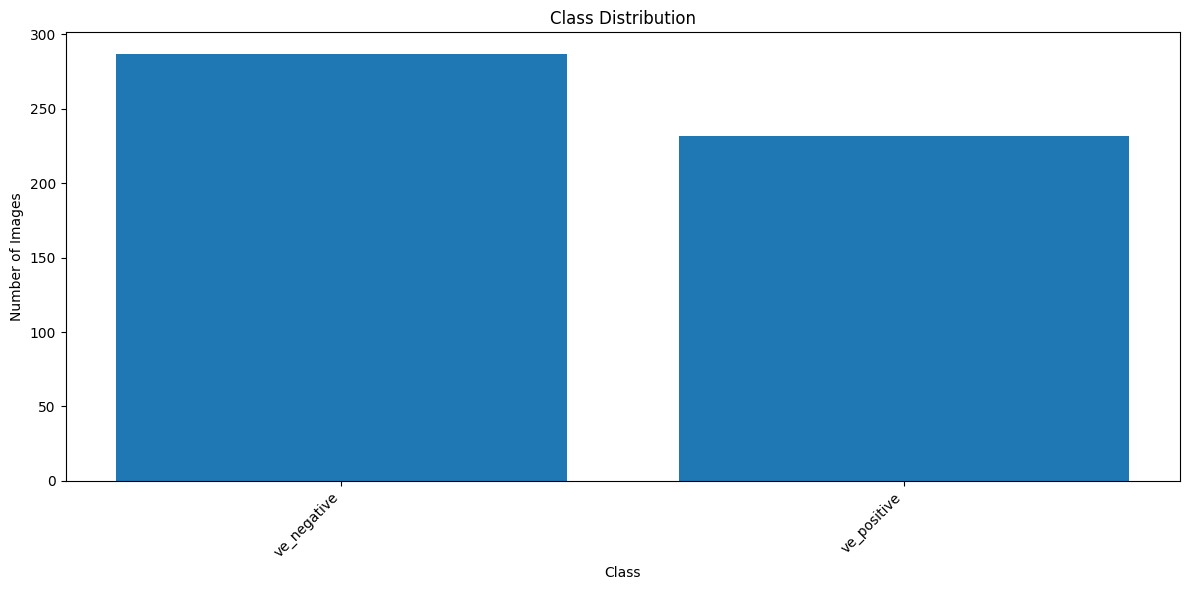

In [7]:
# Visualise class distribution
plt.figure(figsize=(12, 6))

plt.bar(
    class_df["Class"],
    class_df["Number_of_Images"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.tight_layout()
plt.show()

In the next step, I check file extension

In [8]:
# Check file extensions
image_df["extension"] = image_df["filename"].apply(
    lambda x: Path(x).suffix.lower()
)

print(image_df["extension"].value_counts())

extension
.png    519
Name: count, dtype: int64


So all files are images with .png extension, very consistent across the dataset. 

In [9]:
# Check for corrupted/unreadable images

bad_images = []

for path in image_df["path"]:

    try:
        with Image.open(path) as img:
            img.verify() #  Check if an image file is broken or corrupted without actually decoding the full pixel data

    except Exception as e:
        bad_images.append({
            "path": path,
            "error": str(e)
        })

print("Number of corrupted/unreadable images:", len(bad_images))

Number of corrupted/unreadable images: 0


So there is no corrupted/unreadable images in the dataset

In [10]:
# Display problematic images:

bad_images_df = pd.DataFrame(bad_images)

bad_images_df.head()

""


There is also no bad images

Check for duplicate images 

In [11]:
# Check exact duplicate images

hashes = defaultdict(list)

for path in image_df["path"]:

    with open(path, "rb") as f:
        file_hash = hashlib.md5( # create an MD5 cryptographic hash object
            f.read()
        ).hexdigest() # returns the final hash value as a readable string of hexadecimal digits

    hashes[file_hash].append(path)

duplicates = {
    h: paths
    for h, paths in hashes.items()
    if len(paths) > 1
}

print("Number of duplicate groups:", len(duplicates))

for h, paths in list(duplicates.items())[:10]:

    print("\nDuplicate group:")

    for path in paths:
        print(path)

Number of duplicate groups: 0


So, there is no exact duplicate images

In [12]:
# Check near-duplicate images

phashes = defaultdict(list)

for path in image_df["path"]:

    try:

        image = Image.open(path).convert("RGB")

        h = imagehash.phash(image) # calculate the Perceptual Hash (pHash) of an image

        phashes[str(h)].append(path)

    except:
        pass

near_duplicates = {
    h: paths
    for h, paths in phashes.items()
    if len(paths) > 1
}

print(
    "Potential near-duplicate groups:",
    len(near_duplicates)
)

Potential near-duplicate groups: 0


There is also no near-duplicate images

Analyse image dimensions

In [13]:
# Analyse image dimensions

widths = []
heights = []

for path in image_df["path"]:

    try:
        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)

    except:
        widths.append(np.nan)
        heights.append(np.nan)

image_df["width"] = widths
image_df["height"] = heights

image_df.head()

,path,class,filename,extension,width,height
0,..\data\ve_negative\Biospatial_20160603U_1171_...,ve_negative,Biospatial_20160603U_1171_03_03.png,.png,552,369
1,..\data\ve_negative\Biospatial_20160603U_1173_...,ve_negative,Biospatial_20160603U_1173_04_01.png,.png,552,369
2,..\data\ve_negative\Biospatial_20160603U_1174_...,ve_negative,Biospatial_20160603U_1174_03_03.png,.png,552,369
3,..\data\ve_negative\Biospatial_20160603U_1174_...,ve_negative,Biospatial_20160603U_1174_03_04.png,.png,552,369
4,..\data\ve_negative\Biospatial_20160603U_1174_...,ve_negative,Biospatial_20160603U_1174_04_03.png,.png,552,369


In [14]:
# Check unique dimensions:

dimension_counts = (
    image_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

dimension_counts

,width,height,count
0,368,246,387
4,552,369,128
2,442,295,2
1,404,269,1
3,442,296,1


So we can see that 387 images have dimensions 368 x 246, 128 images have dimensions of 552 x 369. And there are 2 images with dimension 442 x 295, 1 image with dimension of 404 x 269 and 1 image with dimention of 442 x 269. As the dimensions are different, we might need to convert the images into the same dimension in the next step of preprocessing. To see if these convertion might affect the geomatric quality of the images, I will have a further look into the dimension ratio. 

Analyse aspect ratio

In [15]:
# Analyse aspect ratio
image_df["aspect_ratio"] = (
    image_df["width"] / image_df["height"]
)

print(image_df["aspect_ratio"].describe())

count    519.000000
mean       1.495950
std        0.000321
min        1.493243
25%        1.495935
50%        1.495935
75%        1.495935
max        1.501859
Name: aspect_ratio, dtype: float64


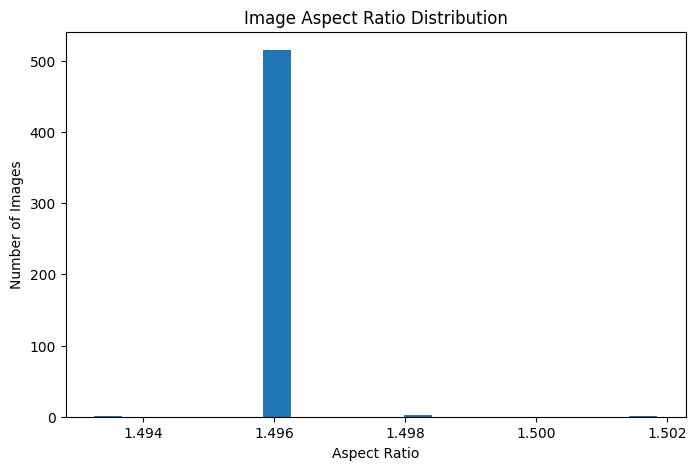

In [19]:
# Visualise

plt.figure(figsize=(8, 5))

plt.hist(
    image_df["aspect_ratio"],
    bins=20
)

plt.xlabel("Aspect Ratio")
plt.ylabel("Number of Images")
plt.title("Image Aspect Ratio Distribution")




plt.savefig("Image Aspect Ratio Distribution", dpi=300, bbox_inches="tight")

plt.show()


So we can see that most of the images have the dimension ration of 1.496 while just very few have different other ratio so the conversion of the images into the same dimension will potentially not affect the geomatric quality of the images. 

Analyse image channel 

In [20]:
# Check image channels
channel_counts = Counter()

for path in image_df["path"]:

    try:
        with Image.open(path) as img:
            channel_counts[img.mode] += 1

    except:
        pass

print(channel_counts)


Counter({'RGB': 511, 'RGBA': 8})


So we can see that while most of the images are RGB, 8 of them are RGBA which might need to be converted to RGB or deleted. I can check randomly the array shape on one image as below. 

In [21]:
# Check actual array shape
sample_path = image_df.iloc[0]["path"]

image = np.array(Image.open(sample_path))

print("Shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum:", image.min())
print("Maximum:", image.max())

Shape: (369, 552, 3)
Data type: uint8
Minimum: 0
Maximum: 215


Analyse pixel value

To analyse pixel value, I also convert all the images to RGB

In [22]:
# Analyse pixel values


pixel_means = []
pixel_stds = []
pixel_mins = []
pixel_maxs = []

for path in image_df["path"]:

    img = np.array(
        Image.open(path).convert("RGB")
    )

    pixel_means.append(img.mean())
    pixel_stds.append(img.std())
    pixel_mins.append(img.min())
    pixel_maxs.append(img.max())

pixel_stats = pd.DataFrame({
    "mean": pixel_means,
    "std": pixel_stds,
    "min": pixel_mins,
    "max": pixel_maxs
})

pixel_stats.describe()

,mean,std,min,max
count,519.000000,519.000000,519.000000,519.000000
mean,98.813983,35.924888,10.603083,239.670520
std,34.062504,9.113064,12.287596,23.549695
min,23.028475,7.948459,0.000000,135.000000
25%,74.315870,29.577758,1.000000,230.000000
50%,95.994919,35.252528,6.000000,254.000000
75%,123.914330,41.785193,16.000000,255.000000
max,203.044682,65.592816,93.000000,255.000000


The analysis of pixel values show that with the mean of 98, the images are genarally dark, with the variation of 35.92 out of 255, so the images are quite reasonable for satelite images. 

In [23]:
# Analyse RGB colour distributions
red_pixels = []
green_pixels = []
blue_pixels = []

for path in image_df["path"]:

    

    red_pixels.extend(img[:, :, 0].flatten())
    green_pixels.extend(img[:, :, 1].flatten())
    blue_pixels.extend(img[:, :, 2].flatten())

In [24]:
# Calculate mean and standard deviation per channel
channel_means = []
channel_stds = []

for path in image_df["path"]:

    img = np.array(
        Image.open(path).convert("RGB")
    ).astype(np.float32)

    channel_means.append(
        img.mean(axis=(0, 1))
    )

    channel_stds.append(
        img.std(axis=(0, 1))
    )

channel_means = np.array(channel_means)
channel_stds = np.array(channel_stds)

print("Mean RGB:")
print(channel_means.mean(axis=0))

print("\nStd RGB:")
print(channel_stds.mean(axis=0))

Mean RGB:
[ 96.12144 107.9693   92.35145]

Std RGB:
[38.157978 35.852528 26.54279 ]


The above results shows that while green is a bit brighter than other colours in the images, red and blue is a little darker. 

Invesitgate whether colour is important in determining classes 

In [25]:
# Check brightness
brightness = []

for path in image_df["path"]:

    img = np.array(
        Image.open(path).convert("RGB")
    ).astype(np.float32)

    brightness.append(img.mean())

image_df = image_df.copy()
image_df["brightness"] = brightness

image_df["brightness"].describe()

count    519.000000
mean      98.813972
std       34.062504
min       23.028475
25%       74.315876
50%       95.994919
75%      123.914326
max      203.044693
Name: brightness, dtype: float64

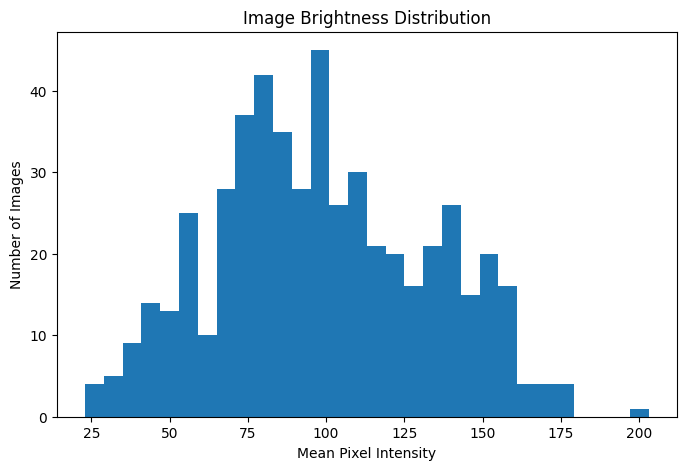

In [26]:
# Plot it

plt.figure(figsize=(8, 5))

plt.hist(
    image_df["brightness"],
    bins=30
)

plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Number of Images")
plt.title("Image Brightness Distribution")
plt.savefig(
    "Image Brightness Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The checking of brightness also shows that the images are more in the dark side or the range. 

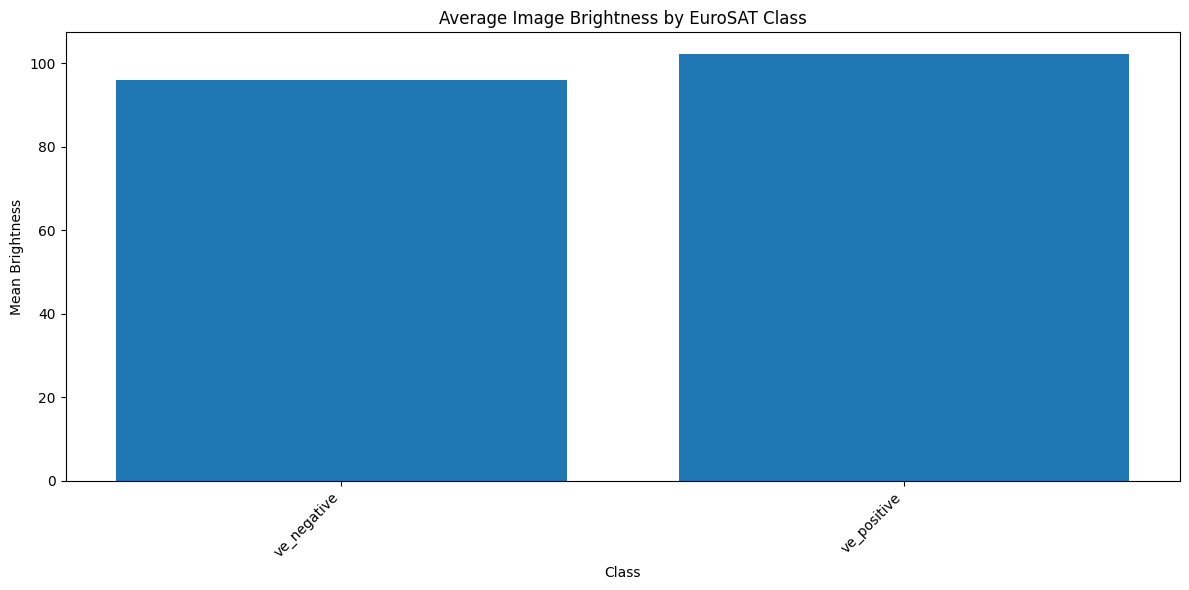

In [27]:
# Compare brightness by class
brightness_by_class = (
    image_df
    .groupby("class")["brightness"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 6))

plt.bar(
    brightness_by_class.index,
    brightness_by_class.values
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Brightness")
plt.xlabel("Class")
plt.title("Average Image Brightness by EuroSAT Class")

plt.tight_layout()
plt.show()

So we can see that ve_negative images are a little darker than the ve_positive one.

In [28]:
# Check very dark and very bright images
print("Darkest images:")

print(
    image_df
    .sort_values("brightness")
    [["path", "class", "brightness"]]
    .head(10)
)

print("\nBrightest images:")

print(
    image_df
    .sort_values("brightness", ascending=False)
    [["path", "class", "brightness"]]
    .head(10)
)

Darkest images:
                                                  path        class  \
7    ..\data\ve_negative\Biospatial_20160603U_1186_...  ve_negative   
46   ..\data\ve_negative\Biospatial_20160603U_1479_...  ve_negative   
36   ..\data\ve_negative\Biospatial_20160603U_1224_...  ve_negative   
3    ..\data\ve_negative\Biospatial_20160603U_1174_...  ve_negative   
311  ..\data\ve_positive\Biospatial_20160702U_2020_...  ve_positive   
34   ..\data\ve_negative\Biospatial_20160603U_1223_...  ve_negative   
48   ..\data\ve_negative\Biospatial_20160603U_1490_...  ve_negative   
441  ..\data\ve_positive\Biospatial_20160702U_2458_...  ve_positive   
35   ..\data\ve_negative\Biospatial_20160603U_1224_...  ve_negative   
145  ..\data\ve_negative\Biospatial_20160702U_2331_...  ve_negative   

     brightness  
7     23.028475  
46    27.139242  
36    27.181795  
3     27.687305  
311   31.036600  
34    33.727695  
48    33.968010  
441   34.030018  
35    34.758133  
145   35.082813  

Bri

All the darkest images are ve_negative, it is in line with the idea that ve_negative images are often darker. 

Check image quality 

Visually inspect randome iamges 

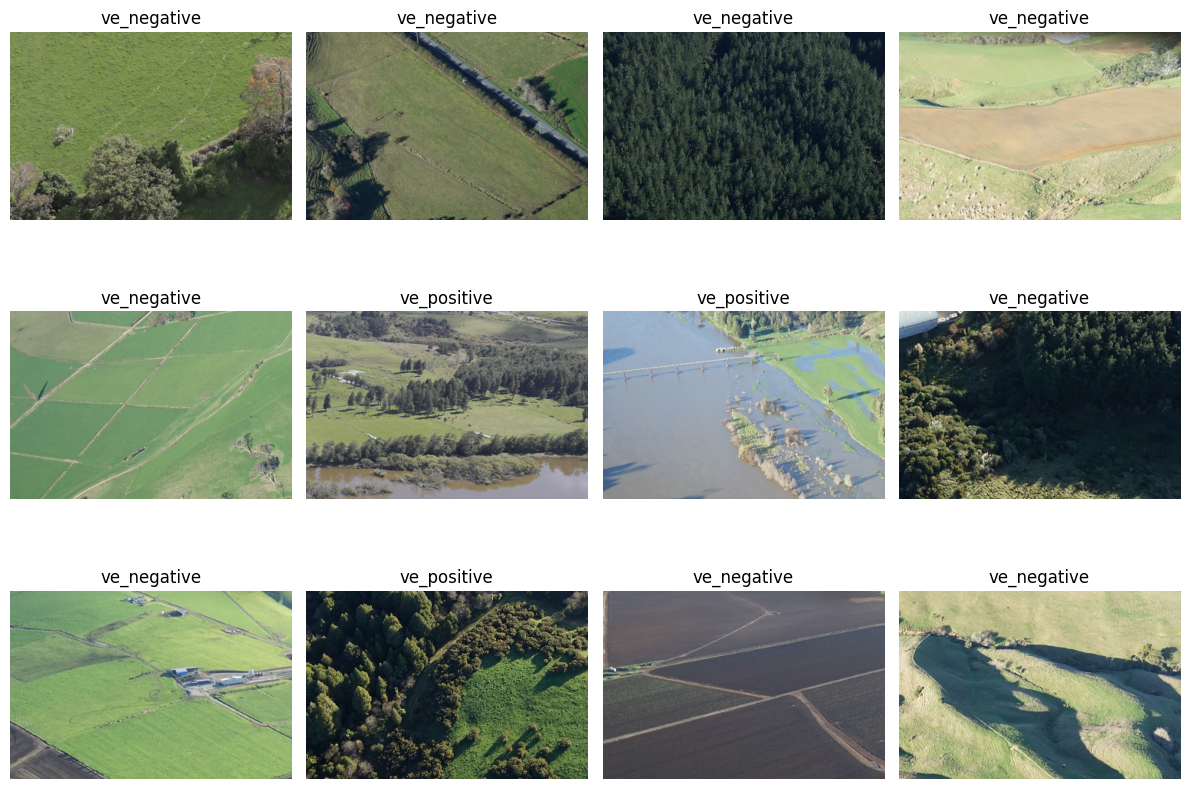

In [29]:
# Display random images
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

sample_images = image_df.sample(
    12,
    random_state=42
)

for ax, (_, row) in zip(axes.flatten(), sample_images.iterrows()):

    image = Image.open(row["path"])

    ax.imshow(image)
    ax.set_title(row["class"])
    ax.axis("off")

plt.tight_layout()
plt.show()

By checking these random images, we can see that the images look visible an usable, not so much plurry, the labels seem to be correct with ve_positive for images with somehow the target kahikatea tree while ve_negative for images of which the trees seem to be not there.The images are not too dark, the image sizes look similar. So I think this sample checking is good 

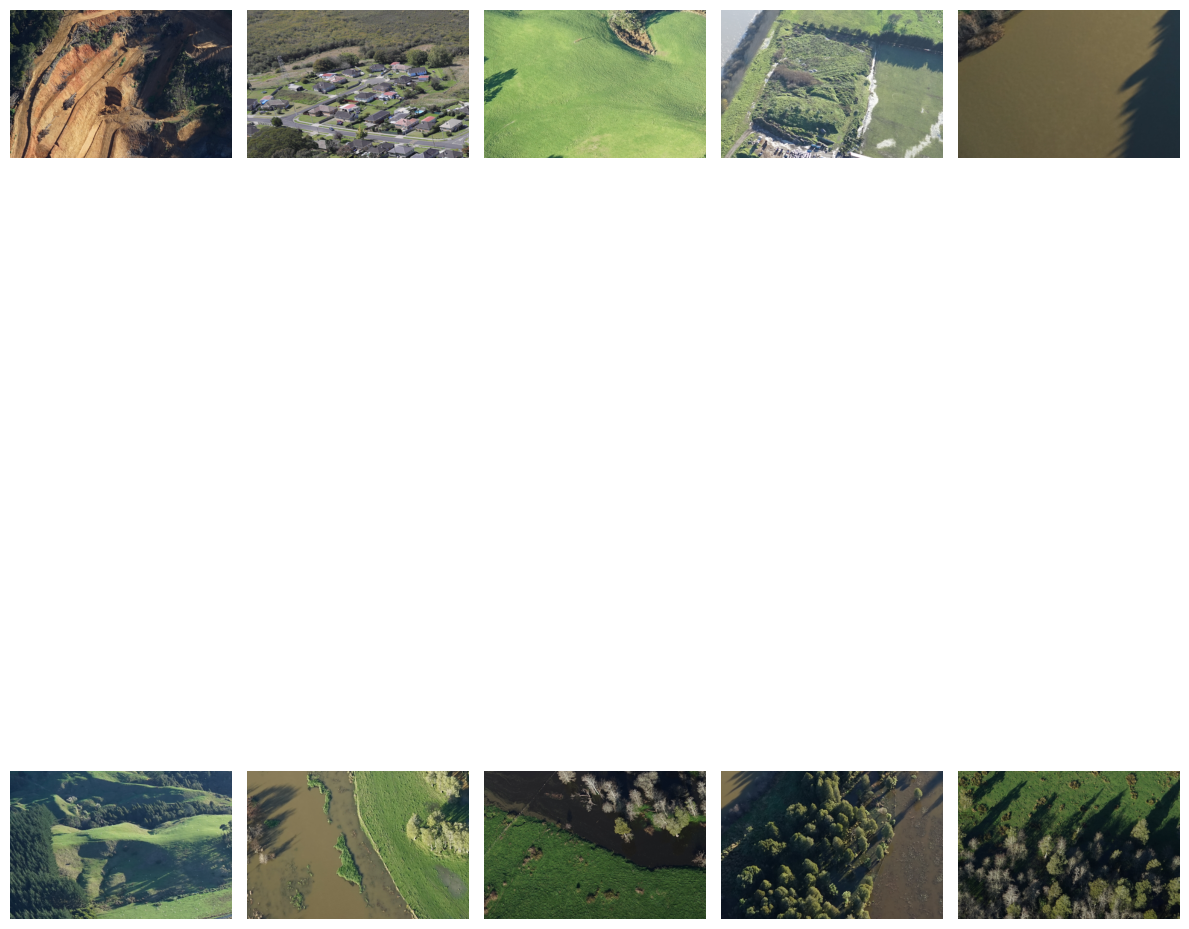

In [30]:
# Display images from every class
fig, axes = plt.subplots(
    len(classes),
    5,
    figsize=(12, 22)
)

for row_idx, cls in enumerate(classes):

    class_images = image_df[
        image_df["class"] == cls
    ].sample(5, random_state=42)

    for col_idx, (_, row) in enumerate(
        class_images.iterrows()
    ):

        image = Image.open(row["path"])

        axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].axis("off")

        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(
                cls,
                fontsize=10
            )

plt.tight_layout()
plt.show()

The above code show randomly 5 images of each class. We can see that overall the quality of these random images is good and the content is consistent with the classes with the 5 above are for the ve_negative and the 5 below are for ve_positive. 

So from the exploratory data analysis, we can see that the dataset is divided into two classes of images with diffent labels of ve_positive and ve_negative. The images in the dataset are consistent in file extension of jpg. There is also no corrupted, unreadable and bad images, no exact duplicate and near duplicate images. 

Checking of the images dimensions also shows that while images in the dataset have different dimensions, which requires conversion them into the same dimension, their dimesion ratios are mostly the same, so the conversion will not affect the geometric quality of the images. 

The checking of the image channel shows that while most images are RGB, 8 images are RGBA. Therefore, in the next step of exploring the data, when checking the pixel valu and colour chanelle, I converted all the images to RGB to be sure. 

The checking of pixel values and colour channel show that the images are generally dark but it is reasonable for satelite images. 

The comparison of images between two classes shows that while ve_negative are generally  a little darker then the ve_positive ones. 

The checking random of some images of the classes also show that the images are quite different between two classes. 

So overall, we can see that the dataset has a good quality for the model. There are only two things for us to consider for preparing the data is that to make sure that they are all converted to RGB and aslo to convert them into the same dimension. 

Task 2: Deep learning models are highly dependent on the quality of the input data. In this task, 
you must prepare the dataset for model development by applying appropriate 
preprocessing techniques. Justify any additional preprocessing steps introduced in Task 
2 that were not identified or applied in Task 1.  
Discuss how the chosen preprocessing steps influence the performance of the deep 
learning models. 

In the next step, I will create the dataset with the processing data, in which, I will resize the images to the same dimensions, conversing them to RGB and standardise pixel from 0 to 1

In [31]:
# Change this to wherever your images are stored



def load_images(df, image_size=(64,64)):
    images = []
    labels = []
    i = 1
    for _, row in df.iloc[:len(df)].iterrows():

        img_path = row["path"]
        print(i) # To see the progress of loading.
        i=i+1
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, image_size)

        img = img.astype(np.float32) / 255.0

        images.append(img)
        labels.append(row["class"])

    return np.array(images), np.array(labels)

load_images(image_df)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


(array([[[[0.49411765, 0.54509807, 0.34509805],
          [0.6784314 , 0.58431375, 0.40784314],
          [0.47843137, 0.47843137, 0.32156864],
          ...,
          [0.41568628, 0.5137255 , 0.30980393],
          [0.40392157, 0.5019608 , 0.32156864],
          [0.41568628, 0.49411765, 0.3019608 ]],
 
         [[0.5568628 , 0.6       , 0.39607844],
          [0.49803922, 0.54901963, 0.3372549 ],
          [0.62352943, 0.61960787, 0.43529412],
          ...,
          [0.3019608 , 0.3882353 , 0.23529412],
          [0.35686275, 0.4392157 , 0.2784314 ],
          [0.3764706 , 0.4627451 , 0.28627452]],
 
         [[0.53333336, 0.58431375, 0.39215687],
          [0.4862745 , 0.54509807, 0.3254902 ],
          [0.57254905, 0.6039216 , 0.40392157],
          ...,
          [0.3647059 , 0.4392157 , 0.26666668],
          [0.36862746, 0.4509804 , 0.27450982],
          [0.42745098, 0.49019608, 0.32941177]],
 
         ...,
 
         [[0.69411767, 0.7019608 , 0.5019608 ],
          [0.56470

I double check the data after processing as below

In [32]:
X, y = load_images(image_df)
print("X shape:", X.shape)
print("y shape:", y.shape)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


So we can see that the whole images 519 has been transformed into the same size 64 x 64 and same color channel - 3 which is RGB

In [33]:
# Analyse pixel values


pixel_means = []
pixel_stds = []
pixel_mins = []
pixel_maxs = []

for img in X:

    

    pixel_means.append(img.mean())
    pixel_stds.append(img.std())
    pixel_mins.append(img.min())
    pixel_maxs.append(img.max())

pixel_stats = pd.DataFrame({
    "mean": pixel_means,
    "std": pixel_stds,
    "min": pixel_mins,
    "max": pixel_maxs
})

pixel_stats.describe()

,mean,std,min,max
count,519.000000,519.000000,519.000000,519.000000
mean,0.386990,0.137021,0.069372,0.856882
std,0.133566,0.035396,0.052240,0.123942
min,0.089852,0.031130,0.000000,0.431373
25%,0.290853,0.113205,0.033333,0.764706
50%,0.376465,0.133575,0.054902,0.890196
75%,0.485471,0.158412,0.094118,0.960784
max,0.796086,0.256382,0.396078,1.000000


The pixel value is also standardised the values from o to 1. So overall I have process the data into the same dimensions, format and also standardise the pixel from 0 to 1. 